In [1]:
import os
import numpy as np
import cv2
from rembg import remove
from tqdm import tqdm  # barre de progression


In [3]:

def get_cntr(seg):
    mask = seg.astype(np.uint8)
    cntrs, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cntr = max(cntrs, key=cv2.contourArea)
    polygon = np.squeeze(cntr, axis=1)
    return polygon

def process_image(img_path, output_path, final_size=512):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Impossible de lire : {img_path}")
        return
    
    try:
        rgba = remove(img)
    except Exception as e:
        print(f"Erreur remove() sur {img_path} : {e}")
        return
    
    alpha = rgba[..., 3]
    _, binary_mask = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    binary_mask = cv2.erode(binary_mask, kernel)

    try:
        cntr = get_cntr(binary_mask)
    except Exception as e:
        print(f"Contour introuvable pour : {img_path}")
        return

    xmin, xmax = np.min(cntr[:, 0]), np.max(cntr[:, 0])
    ymin, ymax = np.min(cntr[:, 1]), np.max(cntr[:, 1])

    cropped_img = rgba[ymin:ymax, xmin:xmax, :3]
    cropped_mask = binary_mask[ymin:ymax, xmin:xmax]

    h, w = cropped_img.shape[:2]
    white_obj = np.ones((h, w, 3), dtype=np.uint8) * 255
    mask_bool = cropped_mask.astype(bool)
    white_obj[mask_bool] = cropped_img[mask_bool]

    scale = min(final_size / h, final_size / w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_obj = cv2.resize(white_obj, (new_w, new_h), interpolation=cv2.INTER_AREA)

    final_img = np.ones((final_size, final_size, 3), dtype=np.uint8) * 255
    x_offset = (final_size - new_w) // 2
    y_offset = (final_size - new_h) // 2
    final_img[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized_obj

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, final_img)

def process_folder(input_root, output_root):
    for root, dirs, files in os.walk(input_root):
        for file in tqdm(files, desc=f"Traitement dans {root}"):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                input_path = os.path.join(root, file)
                
                # Chemin relatif par rapport au dossier source
                relative_path = os.path.relpath(input_path, input_root)
                
                output_path = os.path.join(output_root, relative_path)
                
                process_image(input_path, output_path)

# === Paramètres à modifier ===
dossier_source = "vetement_client"
dossier_destination = "vetement_client_client_process"

process_folder(dossier_source, dossier_destination)


Traitement dans vetement_client: 0it [00:00, ?it/s]
Traitement dans vetement_client\veste: 100%|██████████| 112/112 [04:08<00:00,  2.22s/it]


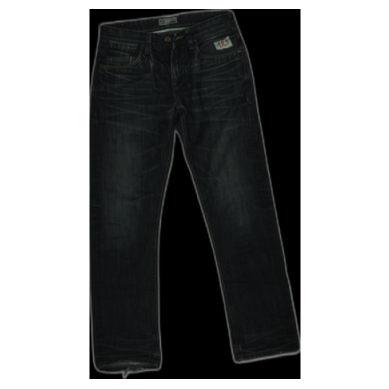

In [5]:
import matplotlib.pyplot as plt

result = process_image("image_test\Pantalons\imgs_20250418_183.png")

if result is not None:
    cv2.imwrite("image_sortie.png", result)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

